In [1]:
!pip install rioxarray rasterio pygris contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.8 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import mapping
import warnings
warnings.filterwarnings('ignore')

print('All imports successful')

All imports successful


In [3]:
gdf = gpd.read_file('/content/drive/MyDrive/EE_exports/SE_GA_counties.geojson')
gdf

,id,ALAND,AWATER,CBSAFP,CLASSFP,COUNTYFP,COUNTYNS,CSAFP,FUNCSTAT,GEOID,INTPTLAT,INTPTLON,LSAD,METDIVFP,MTFCC,NAME,NAMELSAD,STATEFP,geometry
0,0000000000000000002b,1337652375,222886508,25980,H1,179,00357095,496,A,13179,+31.8074582,-081.4578709,06,,G4020,Liberty,Liberty County,13,"POLYGON ((-81.82439 32.01395, -81.82435 32.013..."
1,0000000000000000002c,1133250591,43784915,42340,H1,029,00350496,496,A,13029,+32.0179692,-081.4385431,06,,G4020,Bryan,Bryan County,13,GEOMETRYCOLLECTION (LINESTRING (-81.39329 31.8...
2,0000000000000000002d,1121783898,509841786,42340,H1,051,01694477,496,A,13051,+31.9804037,-081.0851840,06,,G4020,Chatham,Chatham County,13,"POLYGON ((-81.39172 32.09591, -81.39158 32.095..."
3,0000000000000000002e,1240066122,10679265,42340,H1,103,00350219,496,A,13103,+32.3616879,-081.3433566,06,,G4020,Effingham,Effingham County,13,"POLYGON ((-81.548 32.48931, -81.54786 32.48917..."
4,0000000000000000032f,1117201444,369176904,15260,H1,191,00356886,,A,13191,+31.4885058,-081.3722892,06,,G4020,McIntosh,McIntosh County,13,"POLYGON ((-81.66838 31.53617, -81.66833 31.535..."
5,00000000000000000330,1086631796,429153067,15260,H1,127,01671513,,A,13127,+31.2127098,-081.4964503,06,,G4020,Glynn,Glynn County,13,"POLYGON ((-81.78251 31.17158, -81.78247 31.171..."
6,0000000000000000062a,1632473254,392515252,41220,H1,039,01671316,300,A,13039,+30.9133580,-081.6420193,06,,G4020,Camden,Camden County,13,"POLYGON ((-81.937 31.06004, -81.93691 31.05977..."


EPSG:4326
[-81.39171508  31.70519615 -80.78296298  32.23760172]


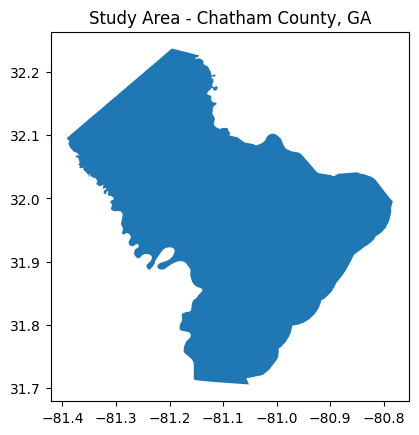

In [4]:
aoi = gdf[gdf['NAME'] == 'Chatham']
aoi

print(aoi.crs)
print(aoi.geometry.total_bounds)
aoi.plot()
plt.title('Study Area - Chatham County, GA')
plt.show()

In [5]:
from rioxarray.merge import merge_arrays

tile_path_2014 = '/content/drive/MyDrive/NE_2014.tif'

image14 = rxr.open_rasterio(tile_path_2014, masked=True).squeeze()
print('2014 image CRS:', image14.rio.crs)
print('2014 image shape:', image14.shape)

2014 image CRS: PROJCS["AEA        WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
2014 image shape: (5000, 5000)


In [6]:
aoi_proj = aoi.to_crs(image14.rio.crs)
clipped14 = image14.rio.clip(aoi_proj.geometry, aoi_proj.crs)
print('Clipped shape:', clipped14.shape)
print('Unique Values:', np.unique(clipped14.values[clipped14.values != clipped14.rio.nodata]))


Clipped shape: (1906, 1942)
Unique Values: [11. 21. 22. 23. 24. 31. 41. 42. 43. 52. 71. 81. 82. 90. 95. nan]


In [7]:
tile_path_2024 = '/content/drive/MyDrive/NE_2024.tif'

image24 = rxr.open_rasterio(tile_path_2024, masked=True).squeeze()
print('2024 image CRS:', image24.rio.crs)
print('2024 image shape:', image24.shape)

2024 image CRS: PROJCS["AEA        WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
2024 image shape: (5000, 5000)


In [8]:
clipped24 = image24.rio.clip(aoi_proj.geometry, aoi_proj.crs)
print('Clipped shape:', clipped24.shape)
print('Unique Values:', np.unique(clipped24.values[clipped24.values != clipped24.rio.nodata]))

Clipped shape: (1906, 1942)
Unique Values: [11. 21. 22. 23. 24. 31. 41. 42. 43. 52. 71. 81. 82. 90. 95. nan]


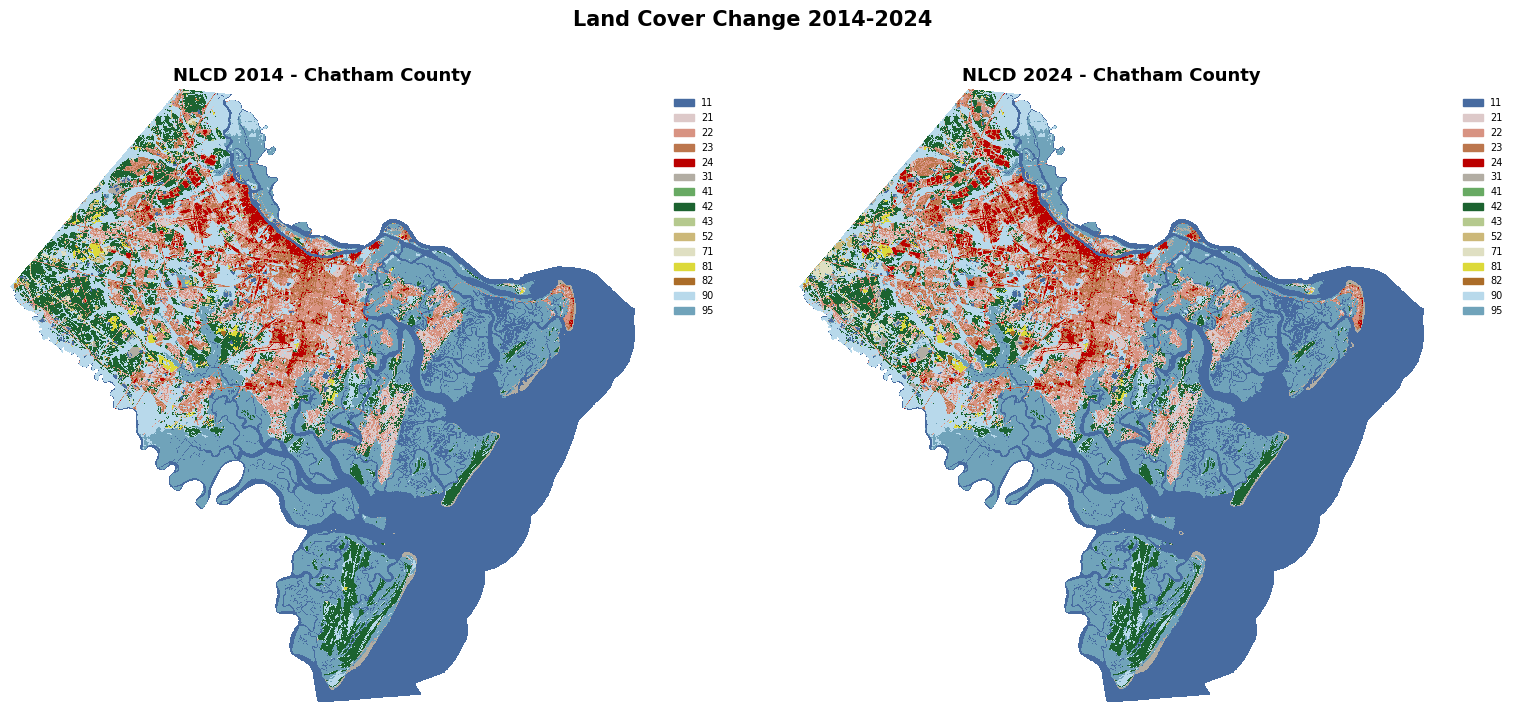

In [9]:
from matplotlib.colors import ListedColormap, BoundaryNorm

nlcd_colors = {
    11: "#476BA0",
    12: "#D1DDF9",
    21: "#DDC9C9",
    22: "#D89382",
    23: "#BC764D",
    24: "#BB0000",
    31: "#B2ADA3",
    41: "#68AA63",
    42: "#1C6330",
    43: "#B5C98E",
    52: "#CCB879",
    71: "#DFDFC2",
    81: "#DCD939",
    82: "#AB6C28",
    90: "#B8D9EB",
    95: "#70A3BA",
}

def plot_nlcd(raster, title, ax):
  data = raster.values
  classes = sorted(nlcd_colors.keys())
  colors = [nlcd_colors[c] for c in classes]

  cmap = ListedColormap(colors)
  bounds = classes + [classes[-1] + 1]
  norm = BoundaryNorm(bounds, cmap.N)

  ax.imshow(data, cmap=cmap, norm=norm, interpolation='nearest')
  ax.set_title(title, fontsize=13, fontweight='bold')
  ax.set_axis_off()

  patches = [mpatches.Patch(color=nlcd_colors[c], label=c) for c in classes if c in np.unique(data)]
  ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, frameon=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,7))

plot_nlcd(clipped14, 'NLCD 2014 - Chatham County', ax1)
plot_nlcd(clipped24, 'NLCD 2024 - Chatham County', ax2)

plt.suptitle('Land Cover Change 2014-2024', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
data14 = clipped14.values.astype(np.int16)
data24 = clipped24.values.astype(np.int16)

print('2014 shape:', data14.shape)
print('2024 shape:', data24.shape)

nodata_mask = (data14 == 128) | (data24 == 128) | \
              (data14 == 255) | (data24 == 255) | \
              (data14 <= 0) | (data24 <= 0)

transition = np.where(nodata_mask, -1, data14 * 100 + data24)

print('Sample unique transitions:', np.unique(transition[transition > 0])[:20])

2014 shape: (1906, 1942)
2024 shape: (1906, 1942)
Sample unique transitions: [1111 1121 1122 1123 1124 1131 1142 1152 1171 1181 1190 1195 2111 2121
 2122 2123 2124 2131 2141 2142]


In [11]:
forest_classes = [41, 42, 43]
ag_classes = [81, 82]
wetland_classes = [90, 95]
developed_classes = [21, 22, 23, 24]

source_classes = forest_classes + ag_classes + wetland_classes

results = []

for from_class in source_classes:
  for to_class in developed_classes:
    code = from_class * 100 + to_class
    pixel_count = np.sum(transition == code)

    if pixel_count > 0:
      area_m2 = pixel_count * 900
      area_acres = area_m2 / 4046.86
      area_sq_mi = area_m2 / 2_589_988

      results.append({
          'from_class': from_class,
          'to_class': to_class,
          'transition': f'{from_class} - {to_class}',
          'pixels': pixel_count,
          'acres': round(area_acres, 1),
          'sq_mi': round(area_sq_mi, 2)
      })

df = pd.DataFrame(results).sort_values('acres', ascending=False)
print(df.to_string(index=False))

 from_class  to_class transition  pixels  acres  sq_mi
         42        23    42 - 23    7293 1621.9   2.53
         42        22    42 - 22    7293 1621.9   2.53
         42        21    42 - 21    7047 1567.2   2.45
         42        24    42 - 24    4340  965.2   1.51
         90        23    90 - 23    4219  938.3   1.47
         90        24    90 - 24    3530  785.1   1.23
         90        22    90 - 22    3416  759.7   1.19
         90        21    90 - 21    2078  462.1   0.72
         81        21    81 - 21     704  156.6   0.24
         95        23    95 - 23     419   93.2   0.15
         81        24    81 - 24     416   92.5   0.14
         95        22    95 - 22     349   77.6   0.12
         81        22    81 - 22     262   58.3   0.09
         95        24    95 - 24     250   55.6   0.09
         81        23    81 - 23     215   47.8   0.07
         82        21    82 - 21     188   41.8   0.07
         82        22    82 - 22     151   33.6   0.05
         8

In [12]:
class_labels = {
    41: 'Deciduous Forest',
    42: 'Evergreen Forest',
    43: 'Mixed Forest',
    81: 'Pasture/Hay',
    82: 'Cultivated Crops',
    90: 'Woody Wetlands',
    95: 'Emergent Wetlands'
}

summary = df.groupby('from_class')[['acres', 'sq_mi']].sum().reset_index()
summary['label'] = summary['from_class'].map(class_labels)
summary = summary.sort_values('acres', ascending=False)
print(summary[['label', 'acres', 'sq_mi']].to_string(index=False))

            label  acres  sq_mi
 Evergreen Forest 5776.2   9.02
   Woody Wetlands 2945.2   4.61
      Pasture/Hay  355.2   0.54
Emergent Wetlands  240.4   0.38
 Cultivated Crops  113.9   0.18
     Mixed Forest   43.4   0.07
 Deciduous Forest    8.4   0.01


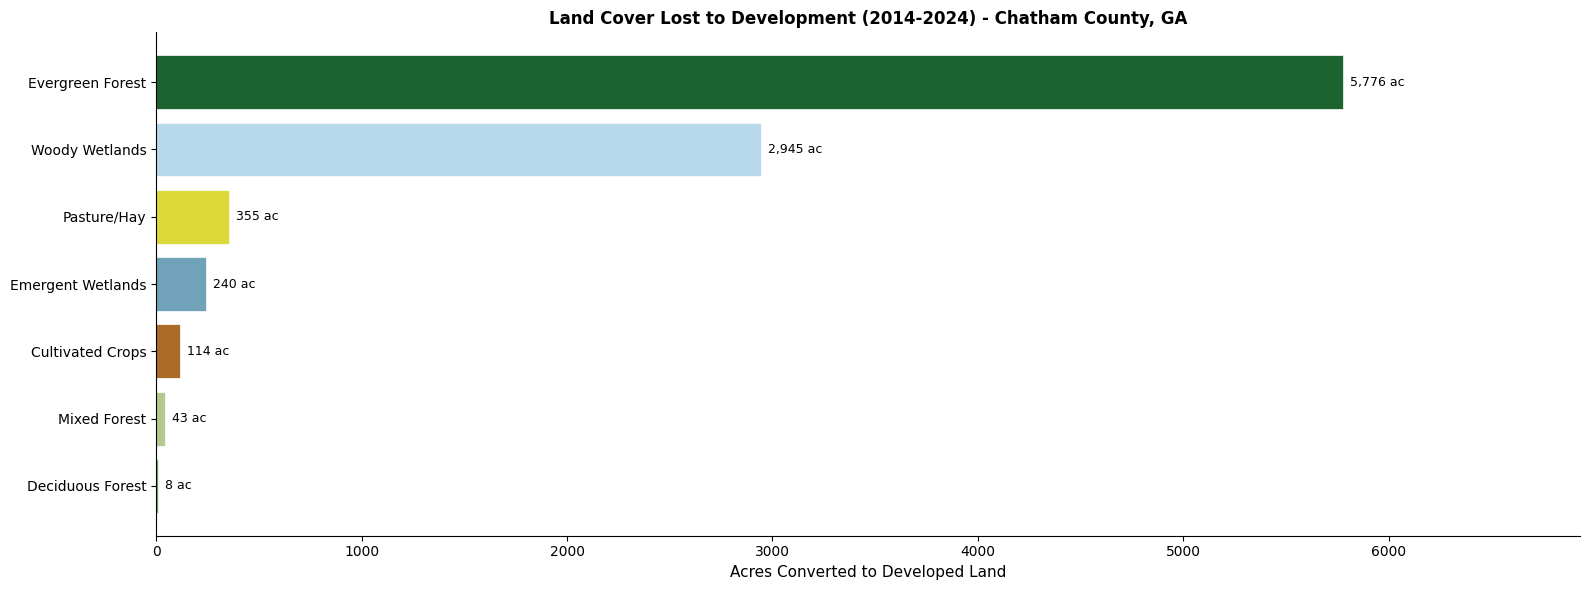

In [13]:
fig, ax = plt.subplots(figsize=(16,6))

bar_colors = {
    'Evergreen Forest':    '#1C6330',
    'Woody Wetlands':      '#B8D9EB',
    'Cultivated Crops':    '#AB6C28',
    'Pasture/Hay':         '#DCD939',
    'Emergent Wetlands':   '#70A3BA',
    'Mixed Forest':        '#B5C98E',
    'Deciduous Forest':    '#68AA63',
}

colors = [bar_colors[l] for l in summary['label']]
bars = ax.barh(summary['label'], summary['acres'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Acres Converted to Developed Land', fontsize=11)
ax.set_title('Land Cover Lost to Development (2014-2024) - Chatham County, GA', fontsize=12, fontweight='bold')
ax.bar_label(bars, fmt='{:,.0f} ac', padding=5, fontsize=9)
ax.set_xlim(0, summary['acres'].max() * 1.2)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
import contextily as ctx
from rasterio.transform import from_bounds

In [14]:
transition_map = np.zeros_like(data14, dtype=np.uint8)

for fc in [41, 42, 43]:
  for tc in [21, 22, 23, 24]:
    transition_map[transition == fc * 100 + tc] = 1

for fc in [90, 95]:
  for tc in [21, 22, 23, 24]:
    transition_map[transition == fc * 100 + tc] = 2

for fc in [81,82]:
  for tc in [21, 22, 23, 24]:
    transition_map[transition == fc * 100 + tc] = 3

transition_map[nodata_mask] = 0

print('Unique Values added in transition map:', np.unique(transition_map))

Unique Values added in transition map: [0 1 2 3]


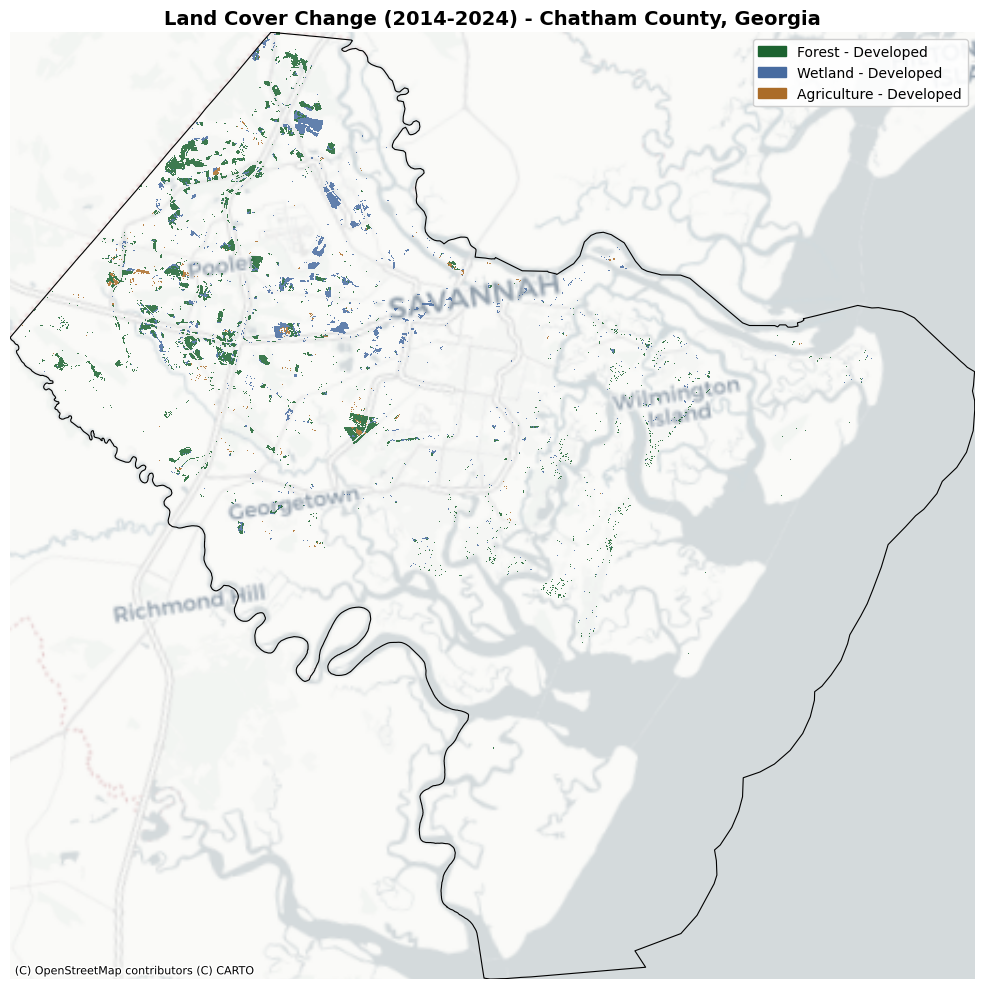

In [16]:
fig, ax = plt.subplots(figsize=(12,10))

left, bottom, right, top = clipped14.rio.bounds()

ax.set_xlim(left, right)
ax.set_ylim(bottom, top)

ctx.add_basemap(
    ax,
    crs=aoi_proj.crs.to_string(),
    source=ctx.providers.CartoDB.Positron,
    zoom=10
)

cmap_colors = ['none', '#1C6330', '#476BA0', '#AB6C28']
cmap = ListedColormap(cmap_colors)
norm = BoundaryNorm([0, 1, 2, 3, 4], len(cmap_colors))

display = np.ma.masked_where((transition_map == 0) | (transition_map == 255), transition_map)


ax.imshow(
    display,
    cmap=cmap,
    norm=norm,
    extent=[left, right, bottom, top],
    origin='upper',
    interpolation='nearest',
    alpha=0.85
)

aoi_proj.boundary.plot(ax=ax, color='black', linewidth=0.8)

legend_elements = [
    mpatches.Patch(color='#1C6330', label='Forest - Developed'),
    mpatches.Patch(color='#476BA0', label='Wetland - Developed'),
    mpatches.Patch(color='#AB6C28', label='Agriculture - Developed')
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, framealpha=0.9)
ax.set_title('Land Cover Change (2014-2024) - Chatham County, Georgia', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig('nlcd_tansition_map.png', dpi=200, bbox_inches='tight')
plt.show()